# Big Data dan Machine Learning dengan PySpark
## NYC Taxi Fare Prediction
---
**Dataset:** New York City Taxi Fare Prediction (Kaggle)  
**Metode Jarak:** Haversine Distance  
**Model:** Random Forest Regressor (PySpark MLlib)  
**Distribusi:** 5 Partisi (1 Master + 5 Worker)

---
## 1. Memuat dan Menyiapkan Data (10 poin)

### Cell 1 — Setup Environment

In [1]:
import os
import shutil
import subprocess

# Auto-detect JAVA_HOME
def find_java_home():
    try:
        result = subprocess.run(
            ['java', '-XshowSettings:property', '-version'],
            capture_output=True, text=True
        )
        for line in result.stderr.split('\n'):
            if 'java.home' in line:
                return line.split('=')[1].strip()
    except:
        pass
    return None

# Auto-detect temp dir
temp_dir = os.path.join(os.path.expanduser('~'), 'spark_temp')

# Bersihkan temp lama
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(temp_dir)

# Set environment
java_home = find_java_home()
if java_home:
    os.environ['JAVA_HOME'] = java_home
    print(f"JAVA_HOME   : {java_home}")
else:
    print("JAVA_HOME   : Tidak ditemukan, pakai default sistem")

os.environ['PYSPARK_PYTHON'] = 'python'
os.environ['PYSPARK_DRIVER_PYTHON'] = 'python'
os.environ['SPARK_LOCAL_DIRS'] = temp_dir
os.environ['TMPDIR'] = temp_dir

if 'JAVA_TOOL_OPTIONS' in os.environ:
    del os.environ['JAVA_TOOL_OPTIONS']

print(f"Temp dir    : {temp_dir}")
print("Environment OK!")

JAVA_HOME   : C:\Program Files\Java\jdk-11.0.30.7-hotspot
Temp dir    : C:\Users\ASUS\spark_temp
Environment OK!


### Cell 2 — Inisialisasi Spark (5 Worker)

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NYC Taxi Fare Prediction") \
    .master("local[5]") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.local.dir", temp_dir) \
    .config("spark.executor.instances", "5") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark OK!", spark.version)

Spark OK! 3.3.2


### Cell 3 — Load Data

In [3]:
df = spark.read.csv("train.csv", header=True, inferSchema=True)

df.printSchema()
df.show(5)
print("Total rows:", df.count())

root
 |-- key: timestamp (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- passenger_count: integer (nullable = true)

+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|                key|fare_amount|    pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|2009-06-15 17:26:21|        4.5|2009-06-16 00:26:21|      -73.844311|      40.721319|        -73.84161|       40.712278|              1|
|2010-01-05 16:52:16|       16.9|2010-01-05 23:52:16|      -74.016048| 

### Cell 4 — Bagi Data ke 5 Partisi (Distribusi ke 5 Node)

In [4]:
from pyspark.sql.functions import spark_partition_id

# Bagi data ke 5 partisi
df = df.repartition(5)

# Verifikasi pembagian
print("=== Pembagian Data ke 5 Node ===")
df.groupBy(spark_partition_id().alias("Node")) \
  .count() \
  .orderBy("Node") \
  .show()

print("Total rows   :", df.count())
print("Jumlah partisi:", df.rdd.getNumPartitions())

=== Pembagian Data ke 5 Node ===
+----+--------+
|Node|   count|
+----+--------+
|   0|11084772|
|   1|11084775|
|   2|11084771|
|   3|11084766|
|   4|11084772|
+----+--------+

Total rows   : 55423856
Jumlah partisi: 5


---
## 2. Eksplorasi Data / EDA (15 poin)

### Cell 5 — Statistik Deskriptif

In [5]:
df.describe(['fare_amount', 'passenger_count', 
             'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude']).show()

+-------+------------------+------------------+------------------+-----------------+------------------+-----------------+
|summary|       fare_amount|   passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude| dropoff_latitude|
+-------+------------------+------------------+------------------+-----------------+------------------+-----------------+
|  count|          55423856|          55423856|          55423856|         55423856|          55423480|         55423480|
|   mean|11.345045601623944|1.6853799201556816|-72.50968444358446|39.91979178688893|-72.51120972971403|39.92068144482936|
| stddev| 20.71083219823207|1.3276643570959297| 12.84888338140217|9.642353041994726|12.782196517830489|9.633345796415208|
|    min|            -300.0|                 0|      -3442.059565|     -3492.263768|      -3442.024565|     -3547.886698|
|    max|          93963.36|               208|       3457.625683|      3408.789565|        3457.62235|      3537.132528|
+-------+---------------

### Cell 6 — Cek Missing Values

In [6]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in df.columns
]).show()

+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|              376|             376|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+



### Cell 7 — Ambil Sample untuk Visualisasi

In [7]:
# Drop kolom timestamp agar bisa convert ke Pandas
df_sample = df.drop('key', 'pickup_datetime') \
              .sample(fraction=0.01, seed=42) \
              .toPandas()

print("Sample size:", len(df_sample))

Sample size: 555492


### Cell 8 — Histogram Distribusi Fare Amount

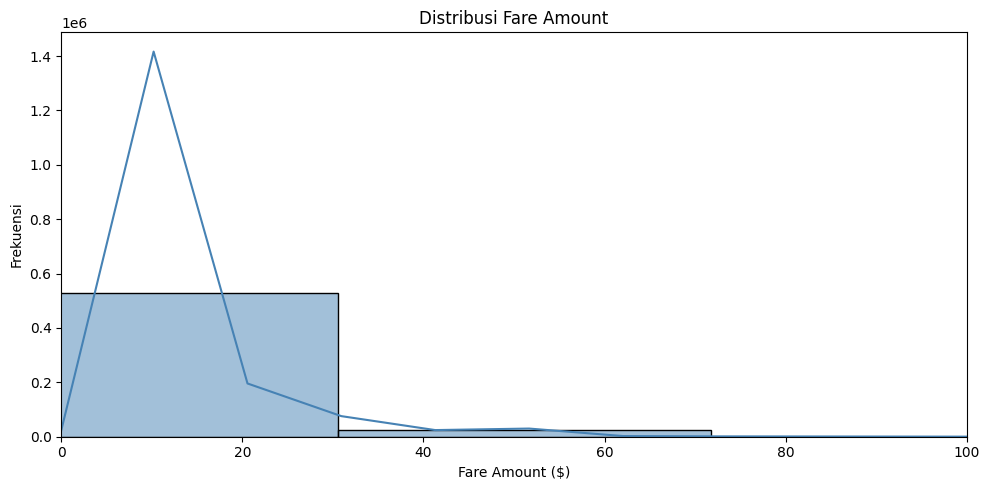

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_sample['fare_amount'], bins=50, 
             kde=True, color='steelblue')
plt.title('Distribusi Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frekuensi')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Cell 9 — Boxplot Fare Amount (Outlier Detection)

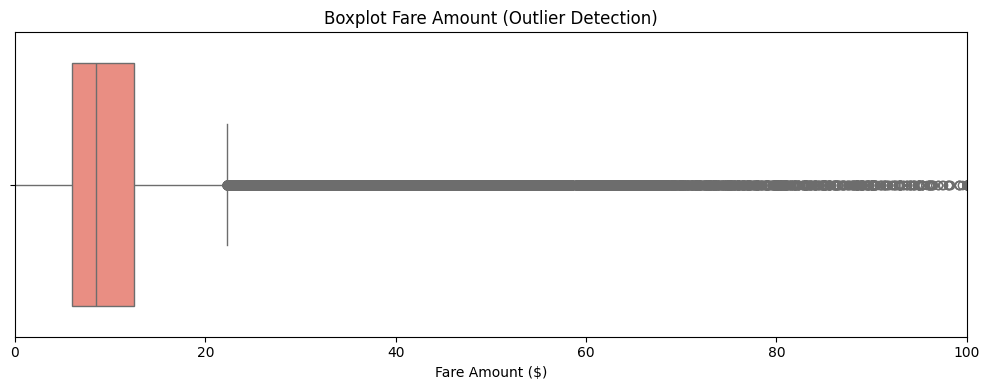

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sample['fare_amount'], color='salmon')
plt.title('Boxplot Fare Amount (Outlier Detection)')
plt.xlabel('Fare Amount ($)')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Cell 10 — Distribusi Passenger Count

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21600\2939252872.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count',


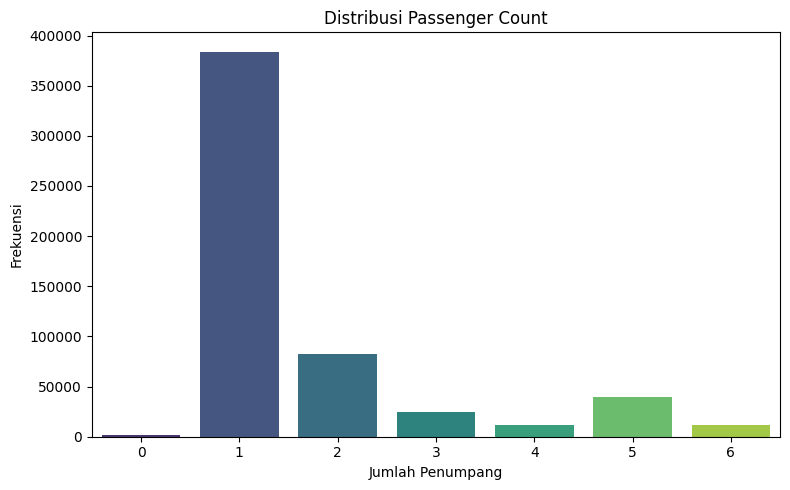

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_count', 
              data=df_sample, palette='viridis')
plt.title('Distribusi Passenger Count')
plt.xlabel('Jumlah Penumpang')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### Cell 11 — Heatmap Korelasi (Sebelum Feature Engineering)

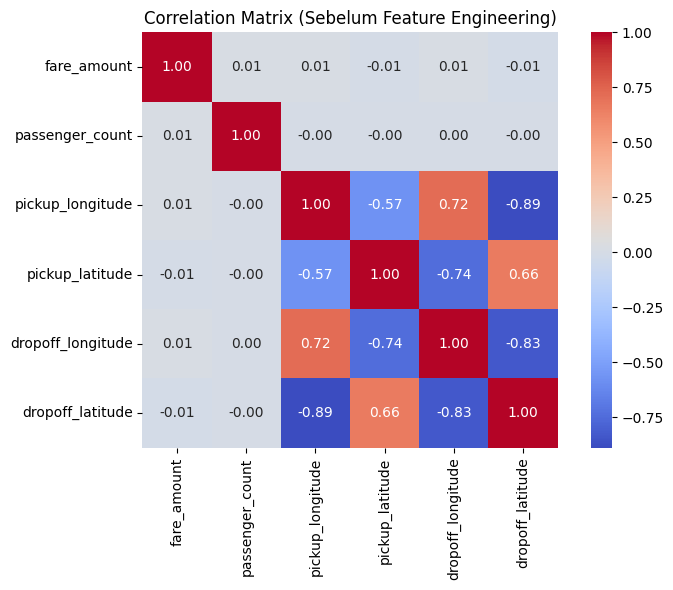

In [11]:
numeric_cols = ['fare_amount', 'passenger_count', 
                'pickup_longitude', 'pickup_latitude',
                'dropoff_longitude', 'dropoff_latitude']

corr_matrix = df_sample[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', square=True)
plt.title('Correlation Matrix (Sebelum Feature Engineering)')
plt.tight_layout()
plt.show()

### Cell 12 — Scatter Plot Sebaran Lokasi NYC

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21600\2919563202.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


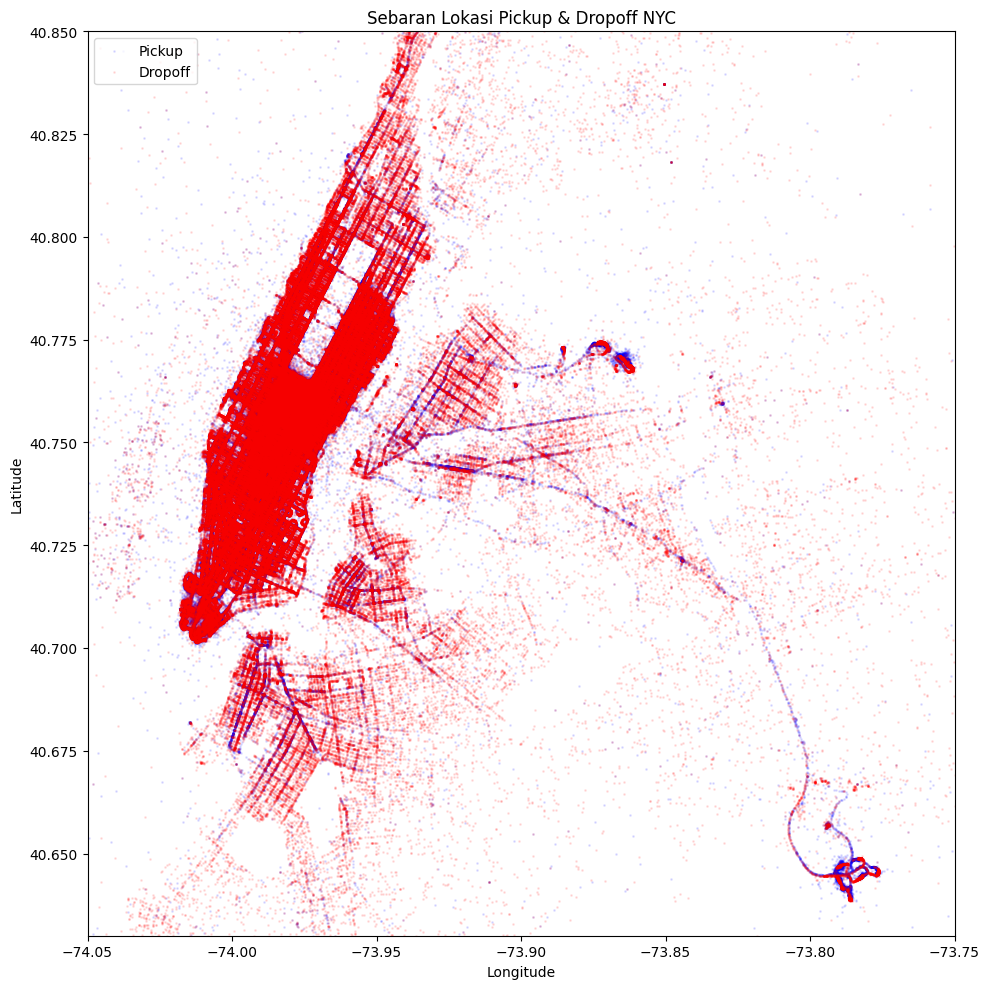

In [12]:
plt.figure(figsize=(10, 10))
plt.scatter(df_sample['pickup_longitude'], 
            df_sample['pickup_latitude'], 
            alpha=0.1, s=1, color='blue', label='Pickup')
plt.scatter(df_sample['dropoff_longitude'], 
            df_sample['dropoff_latitude'], 
            alpha=0.1, s=1, color='red', label='Dropoff')
plt.title('Sebaran Lokasi Pickup & Dropoff NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.05, -73.75)
plt.ylim(40.63, 40.85)
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Preprocessing / Transformasi Data (15 poin)

### Cell 13 — Drop Null & Filter Outlier

In [13]:
from pyspark.sql.functions import col

df_clean = df.dropna()

df_clean = df_clean.filter(
    (col('fare_amount') >= 2.5) & 
    (col('fare_amount') <= 200) &
    (col('passenger_count') >= 1) & 
    (col('passenger_count') <= 6) &
    (col('pickup_longitude').between(-74.05, -73.75)) &
    (col('pickup_latitude').between(40.63, 40.85)) &
    (col('dropoff_longitude').between(-74.05, -73.75)) &
    (col('dropoff_latitude').between(40.63, 40.85))
)

print("Rows sebelum cleaning:", df.count())
print("Rows setelah cleaning:", df_clean.count())

Rows sebelum cleaning: 55423856
Rows setelah cleaning: 53405909


### Cell 14 — Feature Engineering: Haversine Distance

Haversine menghitung jarak antara 2 titik di permukaan bumi (garis lurus mengikuti kelengkungan bumi). Rumus ini memperhitungkan bahwa bumi berbentuk bulat, bukan datar.

In [14]:
from pyspark.sql.functions import col, lit, radians, sin, cos, atan2, sqrt

# Radius bumi dalam km
R = 6371.0

# Hitung Haversine Distance
df_feat = df_clean.withColumn('dlat', radians(col('dropoff_latitude') - col('pickup_latitude'))) \
    .withColumn('dlon', radians(col('dropoff_longitude') - col('pickup_longitude'))) \
    .withColumn('a',
        sin(col('dlat') / 2) ** 2 +
        cos(radians(col('pickup_latitude'))) *
        cos(radians(col('dropoff_latitude'))) *
        sin(col('dlon') / 2) ** 2
    ) \
    .withColumn('distance_km',
        lit(R) * 2 * atan2(sqrt(col('a')), sqrt(1 - col('a')))
    ) \
    .drop('dlat', 'dlon', 'a')

# Filter jarak yang tidak wajar
df_feat = df_feat.filter(
    (col('distance_km') >= 0.5) & 
    (col('distance_km') <= 60)
)

df_feat.select('fare_amount', 'distance_km', 'passenger_count').show(10)
print("Rows setelah feature engineering:", df_feat.count())

+-----------+------------------+---------------+
|fare_amount|       distance_km|passenger_count|
+-----------+------------------+---------------+
|       10.2| 4.032305884759099|              3|
|        4.1|0.5625969693812568|              2|
|       20.0|1.8222755683232068|              2|
|        4.9|0.8937570358383281|              1|
|        6.5|0.6651005613740877|              1|
|        7.3|  2.20858632761579|              1|
|       14.5| 8.468281004723465|              1|
|        6.0|1.3495059461847627|              2|
|       17.0| 7.496312986087142|              2|
|        5.7|1.2477961045373507|              1|
+-----------+------------------+---------------+
only showing top 10 rows

Rows setelah feature engineering: 51230619


### Cell 15 — Pilih 3 Kolom Final

In [15]:
# Dataset final 3 kolom
df_final = df_feat.select('distance_km', 'passenger_count', 'fare_amount')

df_final.show(10)
print("Total rows dataset final:", df_final.count())
df_final.describe().show()

+------------------+---------------+-----------+
|       distance_km|passenger_count|fare_amount|
+------------------+---------------+-----------+
| 4.032305884759099|              3|       10.2|
|0.5625969693812568|              2|        4.1|
|1.8222755683232068|              2|       20.0|
|0.8937570358383281|              1|        4.9|
|0.6651005613740877|              1|        6.5|
|  2.20858632761579|              1|        7.3|
| 8.468281004723465|              1|       14.5|
|1.3495059461847627|              2|        6.0|
| 7.496312986087142|              2|       17.0|
|1.2477961045373507|              1|        5.7|
+------------------+---------------+-----------+
only showing top 10 rows

Total rows dataset final: 51230619
+-------+------------------+------------------+------------------+
|summary|       distance_km|   passenger_count|       fare_amount|
+-------+------------------+------------------+------------------+
|  count|          51230619|          51230619|     

### Cell 16 — Korelasi Setelah Feature Engineering

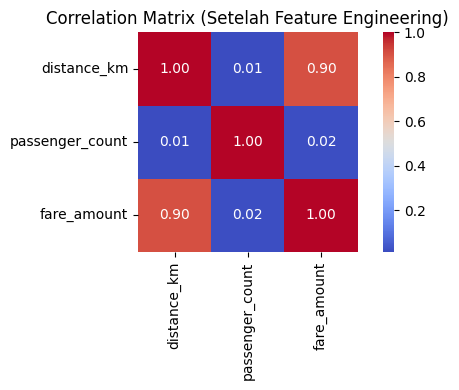

In [16]:
# Sample untuk visualisasi korelasi
df_corr = df_final.sample(fraction=0.01, seed=42).toPandas()

corr_after = df_corr[['distance_km', 'passenger_count', 'fare_amount']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_after, annot=True, fmt='.2f', 
            cmap='coolwarm', square=True)
plt.title('Correlation Matrix (Setelah Feature Engineering)')
plt.tight_layout()
plt.show()

### Cell 17 — Scatter Plot Distance vs Fare

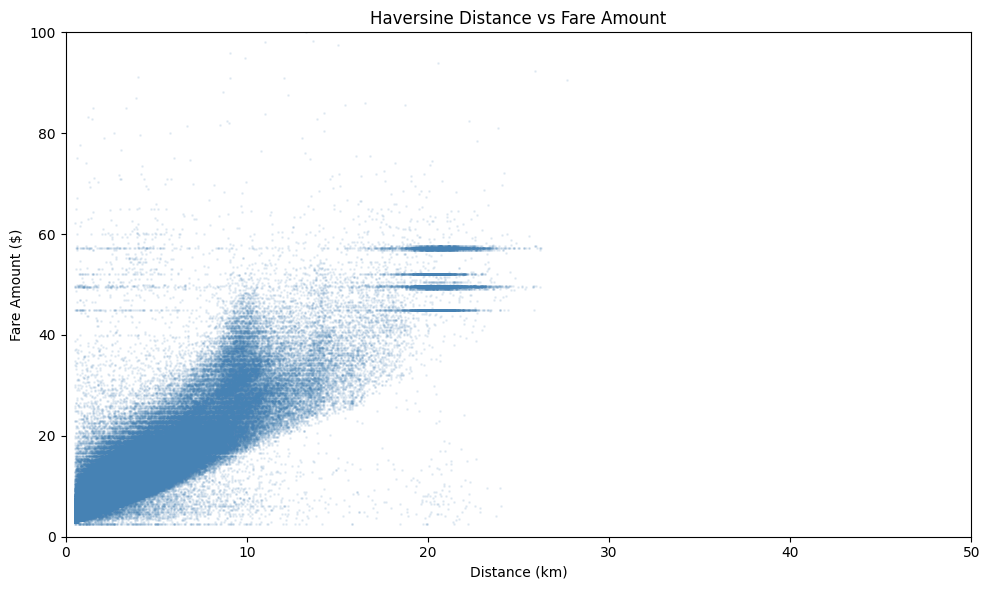

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df_corr['distance_km'], df_corr['fare_amount'], 
            alpha=0.1, s=1, color='steelblue')
plt.title('Haversine Distance vs Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 50)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

---
## 4. Pemodelan dengan PySpark MLlib (25 poin)

Model yang digunakan: **Random Forest Regressor** — cocok untuk data non-linear, robust terhadap outlier, dan tidak mudah overfit.

### Cell 18 — VectorAssembler

In [18]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ['distance_km', 'passenger_count']

assembler = VectorAssembler(
    inputCols=feature_cols, 
    outputCol='features'
)

df_assembled = assembler.transform(df_final)
df_assembled.select('features', 'fare_amount').show(5)

+--------------------+-----------+
|            features|fare_amount|
+--------------------+-----------+
|[4.03230588475909...|       10.2|
|[0.56259696938125...|        4.1|
|[1.82227556832320...|       20.0|
|[0.89375703583832...|        4.9|
|[0.66510056137408...|        6.5|
+--------------------+-----------+
only showing top 5 rows



### Cell 19 — Split Data Train & Test (80:20)

In [19]:
train_df, test_df = df_assembled.randomSplit([0.8, 0.2], seed=42)

print("Train size:", train_df.count())
print("Test size :", test_df.count())

Train size: 40982881
Test size : 10247738


### Cell 20 — Training Model Random Forest

In [20]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol='features',
    labelCol='fare_amount',
    numTrees=50,
    maxDepth=5,
    seed=42
)

print("Training model Random Forest...")
print("numTrees=50, maxDepth=5")
rf_model = rf.fit(train_df)
print("Model selesai ditraining!")

Training model Random Forest...
numTrees=50, maxDepth=5
Model selesai ditraining!


---
## 5. Evaluasi Model (15 poin)

### Cell 21 — Prediksi & Evaluasi

In [21]:
from pyspark.ml.evaluation import RegressionEvaluator

# Prediksi
predictions = rf_model.transform(test_df)
predictions.select('fare_amount', 'prediction', 'distance_km', 'passenger_count').show(10)

# Evaluasi
evaluator_rmse = RegressionEvaluator(
    labelCol='fare_amount', predictionCol='prediction', metricName='rmse')
evaluator_mae = RegressionEvaluator(
    labelCol='fare_amount', predictionCol='prediction', metricName='mae')
evaluator_r2 = RegressionEvaluator(
    labelCol='fare_amount', predictionCol='prediction', metricName='r2')

rmse = evaluator_rmse.evaluate(predictions)
mae  = evaluator_mae.evaluate(predictions)
r2   = evaluator_r2.evaluate(predictions)

print("=== Hasil Evaluasi Model ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R\u00b2   : {r2:.4f}")

+-----------+-----------------+------------------+---------------+
|fare_amount|       prediction|       distance_km|passenger_count|
+-----------+-----------------+------------------+---------------+
|        4.0|7.774846208226927|0.5000011656686771|              1|
|        6.5|7.774846208226927|0.5000043876450385|              1|
|        4.0|7.291318129572158|0.5000050090665711|              3|
|        5.0|7.774846208226927|0.5000078126275194|              1|
|        4.1|8.391775945260612|0.5000138609128969|              6|
|        3.7|7.159264314253168|0.5000154121100656|              5|
|        4.9|7.291318129572158|0.5000190431178883|              3|
|        4.1|7.774846208226927|0.5000240723749474|              1|
|        3.3|7.159264314253168|0.5000296894284035|              5|
|        3.3|7.774846208226927|0.5000300990445932|              1|
+-----------+-----------------+------------------+---------------+
only showing top 10 rows

=== Hasil Evaluasi Model ===
RMSE : 

### Cell 22 — Visualisasi Prediksi vs Aktual

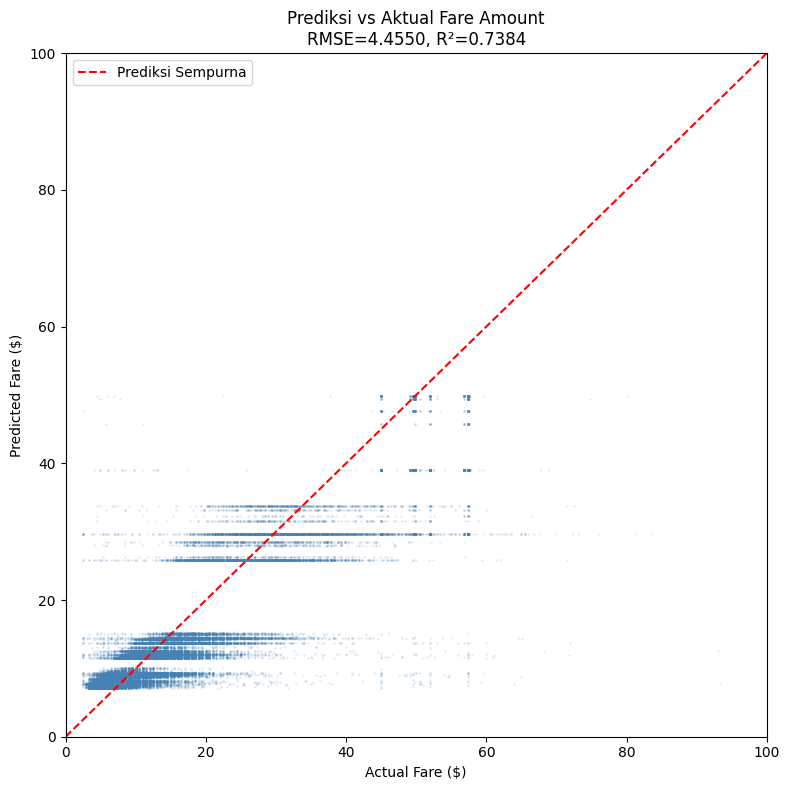

In [22]:
# Sample prediksi untuk visualisasi
pred_sample = predictions.select('fare_amount', 'prediction') \
                         .sample(fraction=0.01, seed=42) \
                         .toPandas()

plt.figure(figsize=(8, 8))
plt.scatter(pred_sample['fare_amount'], 
            pred_sample['prediction'], 
            alpha=0.1, s=1, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', label='Prediksi Sempurna')
plt.title(f'Prediksi vs Aktual Fare Amount\nRMSE={rmse:.4f}, R\u00b2={r2:.4f}')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

### Cell 23 — Feature Importance

=== Feature Importance ===
           Feature  Importance
0      distance_km    0.998758
1  passenger_count    0.001242


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21600\2891257976.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


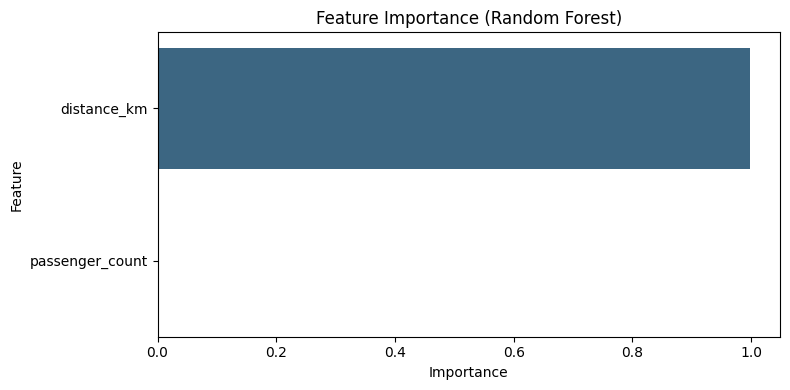

In [23]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.featureImportances.toArray()
}).sort_values('Importance', ascending=False)

print("=== Feature Importance ===")
print(feature_importance)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

---
## 6. Hyperparameter Tuning (10 poin)

Hyperparameter yang di-tuning pada Random Forest:
- **numTrees**: Jumlah pohon di dalam forest
- **maxDepth**: Kedalaman maksimum setiap pohon

Menggunakan TrainValidationSplit (lebih ringan dari CrossValidator untuk dataset besar).

### Cell 24 — Hyperparameter Tuning dengan TrainValidationSplit

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

# Buat parameter grid
param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [50, 100]) \
    .addGrid(rf.maxDepth, [5, 7]) \
    .build()

# TrainValidationSplit (Pengganti CrossValidator)
tvs = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=param_grid,
    evaluator=evaluator_rmse,
    trainRatio=0.8,
    seed=42
)

print(f"Mulai hyperparameter tuning...")
print(f"Total kombinasi: {len(param_grid)}")

tvs_model = tvs.fit(train_df)
best_model = tvs_model.bestModel

print("\n=== Best Hyperparameters ===")
print(f"Best numTrees: {best_model.getNumTrees}")
print(f"Best maxDepth: {best_model.getMaxDepth()}")

Mulai hyperparameter tuning...
Total kombinasi: 4

=== Best Hyperparameters ===
Best numTrees: 50
Best maxDepth: 7


### Cell 25 — Evaluasi Setelah Tuning

In [25]:
# Prediksi dengan model terbaik
predictions_tuned = best_model.transform(test_df)

rmse_tuned = evaluator_rmse.evaluate(predictions_tuned)
mae_tuned  = evaluator_mae.evaluate(predictions_tuned)
r2_tuned   = evaluator_r2.evaluate(predictions_tuned)

print("============================================")
print("=== Perbandingan Sebelum vs Sesudah Tuning ===")
print("============================================")
print(f"{'Metrik':<8} {'Sebelum':>10} {'Sesudah':>10} {'Perubahan':>10}")
print("-" * 42)
print(f"{'RMSE':<8} {rmse:>10.4f} {rmse_tuned:>10.4f} {rmse-rmse_tuned:>+10.4f}")
print(f"{'MAE':<8} {mae:>10.4f} {mae_tuned:>10.4f} {mae-mae_tuned:>+10.4f}")
print(f"{'R\u00b2':<8} {r2:>10.4f} {r2_tuned:>10.4f} {r2_tuned-r2:>+10.4f}")

=== Perbandingan Sebelum vs Sesudah Tuning ===
Metrik      Sebelum    Sesudah  Perubahan
------------------------------------------
RMSE         4.4550     4.3920    +0.0630
MAE          2.8064     2.7349    +0.0715
R²           0.7384     0.7458    +0.0073


### Cell 26 — Visualisasi Perbandingan Sebelum vs Sesudah Tuning

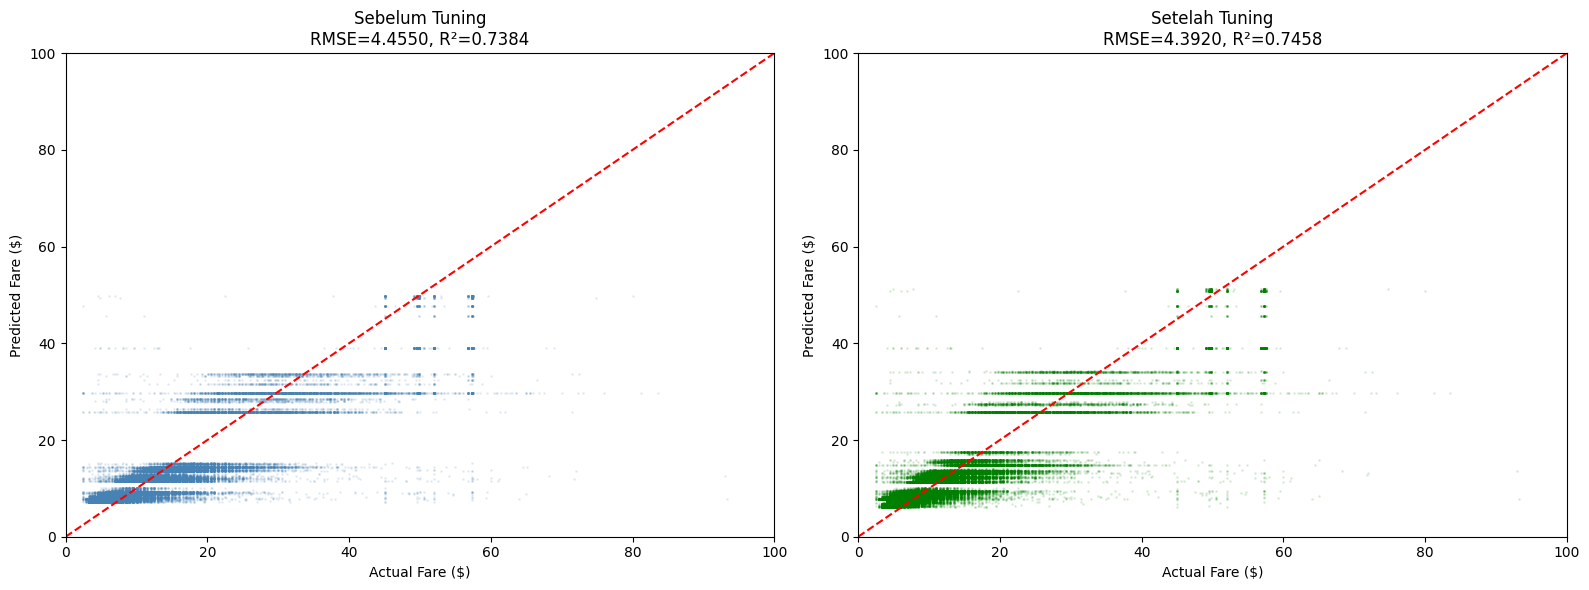

In [26]:
pred_tuned_sample = predictions_tuned.select('fare_amount', 'prediction') \
                                     .sample(fraction=0.01, seed=42) \
                                     .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum Tuning
axes[0].scatter(pred_sample['fare_amount'], 
                pred_sample['prediction'], 
                alpha=0.1, s=1, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--')
axes[0].set_title(f'Sebelum Tuning\nRMSE={rmse:.4f}, R\u00b2={r2:.4f}')
axes[0].set_xlabel('Actual Fare ($)')
axes[0].set_ylabel('Predicted Fare ($)')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Setelah Tuning
axes[1].scatter(pred_tuned_sample['fare_amount'], 
                pred_tuned_sample['prediction'], 
                alpha=0.1, s=1, color='green')
axes[1].plot([0, 100], [0, 100], 'r--')
axes[1].set_title(f'Setelah Tuning\nRMSE={rmse_tuned:.4f}, R\u00b2={r2_tuned:.4f}')
axes[1].set_xlabel('Actual Fare ($)')
axes[1].set_ylabel('Predicted Fare ($)')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Cell 27 — Feature Importance Setelah Tuning

=== Feature Importance Setelah Tuning ===
           Feature  Importance
0      distance_km    0.998791
1  passenger_count    0.001209


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21600\697325320.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


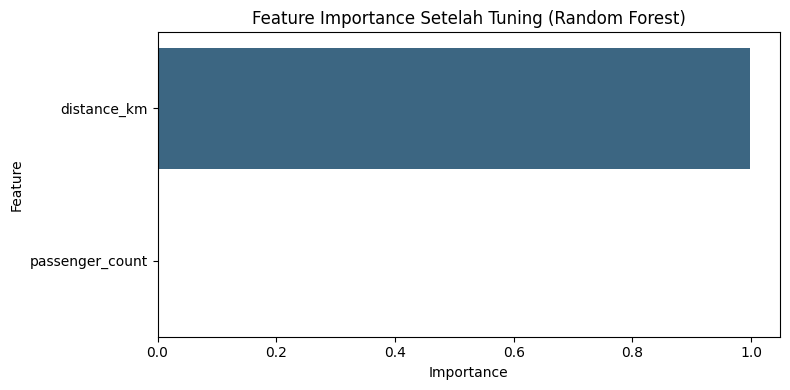

In [27]:
feature_importance_tuned = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.featureImportances.toArray()
}).sort_values('Importance', ascending=False)

print("=== Feature Importance Setelah Tuning ===")
print(feature_importance_tuned)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance_tuned, palette='viridis')
plt.title('Feature Importance Setelah Tuning (Random Forest)')
plt.tight_layout()
plt.show()

---
## Prediksi Test Data (Bonus)

### Cell 28 — Prediksi test.csv

In [28]:
from pyspark.sql.functions import date_format, radians, sin, cos, atan2, sqrt, lit
from pyspark.sql.functions import abs as spark_abs
from pyspark.sql.types import TimestampType, DateType

# Load test.csv
df_test = spark.read.csv("test.csv", header=True, inferSchema=True)

# Convert kolom timestamp ke string
timestamp_cols = [f.name for f in df_test.schema.fields 
                  if isinstance(f.dataType, (TimestampType, DateType))]
print("Kolom timestamp:", timestamp_cols)

for c in timestamp_cols:
    df_test = df_test.withColumn(c, 
                date_format(col(c), 'yyyy-MM-dd HH:mm:ss'))

# Preprocessing
df_test_clean = df_test.dropna()
df_test_clean = df_test_clean.filter(
    (col('pickup_longitude').between(-74.05, -73.75)) &
    (col('pickup_latitude').between(40.63, 40.85)) &
    (col('dropoff_longitude').between(-74.05, -73.75)) &
    (col('dropoff_latitude').between(40.63, 40.85))
)

# Hitung Haversine Distance
R = 6371.0
df_test_feat = df_test_clean \
    .withColumn('dlat', radians(col('dropoff_latitude') - col('pickup_latitude'))) \
    .withColumn('dlon', radians(col('dropoff_longitude') - col('pickup_longitude'))) \
    .withColumn('a',
        sin(col('dlat') / 2) ** 2 +
        cos(radians(col('pickup_latitude'))) *
        cos(radians(col('dropoff_latitude'))) *
        sin(col('dlon') / 2) ** 2
    ) \
    .withColumn('distance_km',
        lit(R) * 2 * atan2(sqrt(col('a')), sqrt(1 - col('a')))
    ) \
    .drop('dlat', 'dlon', 'a')

# Filter distance
df_test_feat = df_test_feat.filter(
    (col('distance_km') >= 0.5) &
    (col('distance_km') <= 60)
)

# Assembler & Prediksi
df_test_assembled = assembler.transform(
    df_test_feat.select('key', 'distance_km', 'passenger_count')
)

test_predictions = best_model.transform(df_test_assembled)

# Simpan hasil prediksi
test_predictions.select('key', 'prediction') \
    .withColumnRenamed('prediction', 'fare_amount') \
    .toPandas() \
    .to_csv('submission.csv', index=False)

print("Submission berhasil disimpan!")
print("Total prediksi:", test_predictions.count())

Kolom timestamp: ['key', 'pickup_datetime']
Submission berhasil disimpan!
Total prediksi: 9420


### Cell 29 — Stop Spark Session

In [29]:
spark.stop()
print("Spark session dihentikan.")

Spark session dihentikan.
